In [11]:
# Imports
import os
import sys
from sklearn.model_selection import train_test_split

# ----File Stitching----
# If in results_cnn folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "results_cnn":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

/Users/hayeonchung/Downloads/Mamalakis Graduate Research/MamalakisResearch
Hayeon Chung recognized as user.
processing model: CNRM_ESM2-1


<>:8: SyntaxWarning: invalid escape sequence '\c'
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/2802897405.py:8: SyntaxWarning: invalid escape sequence '\c'
  return x - 273.15, "$^{\circ}$C"
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


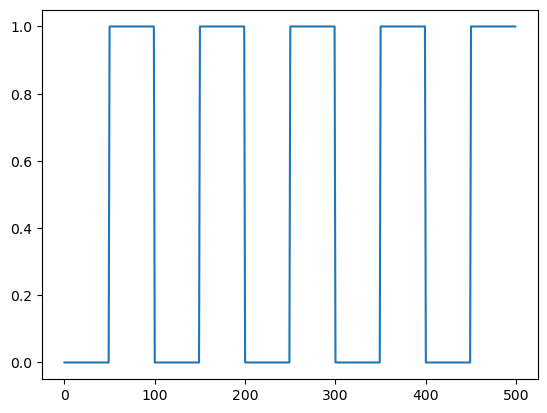

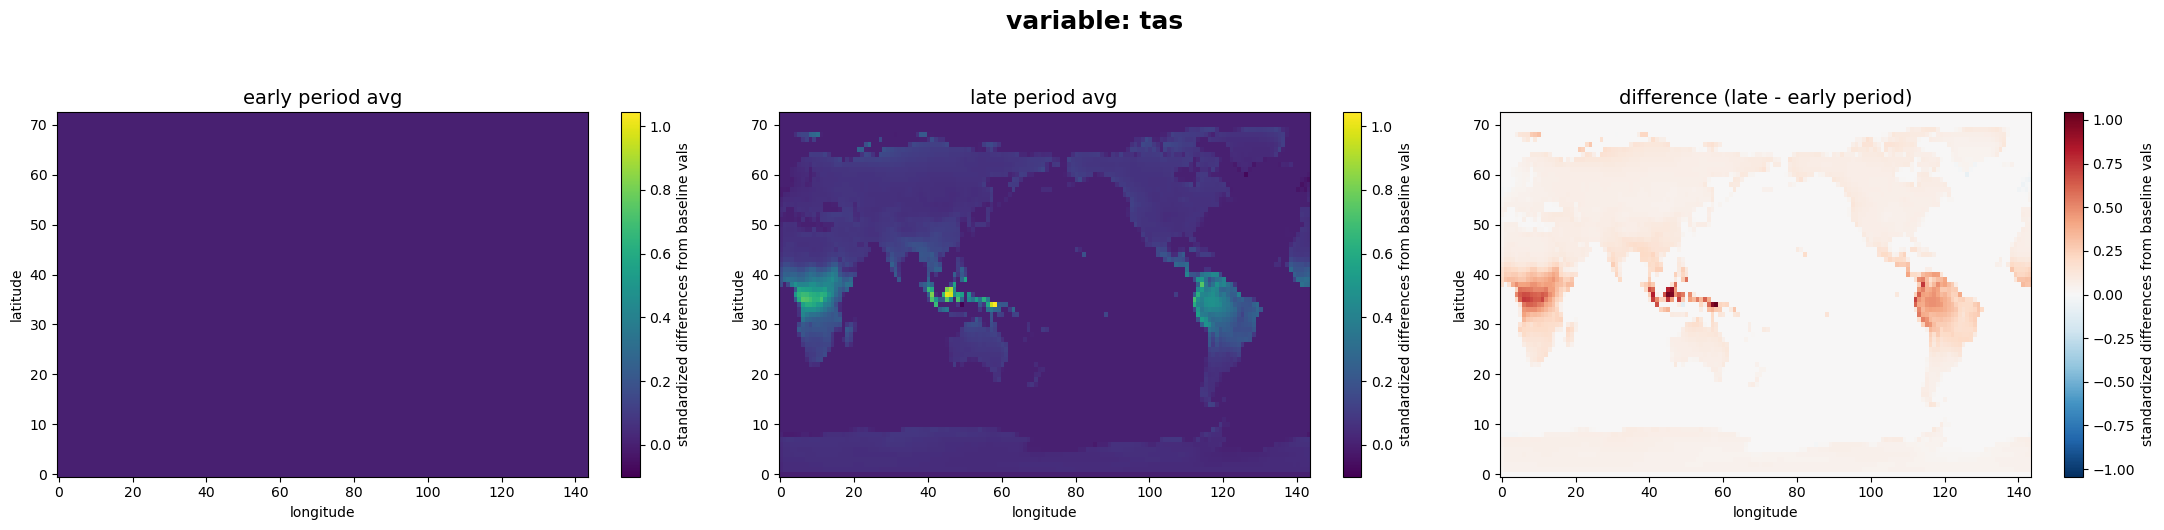

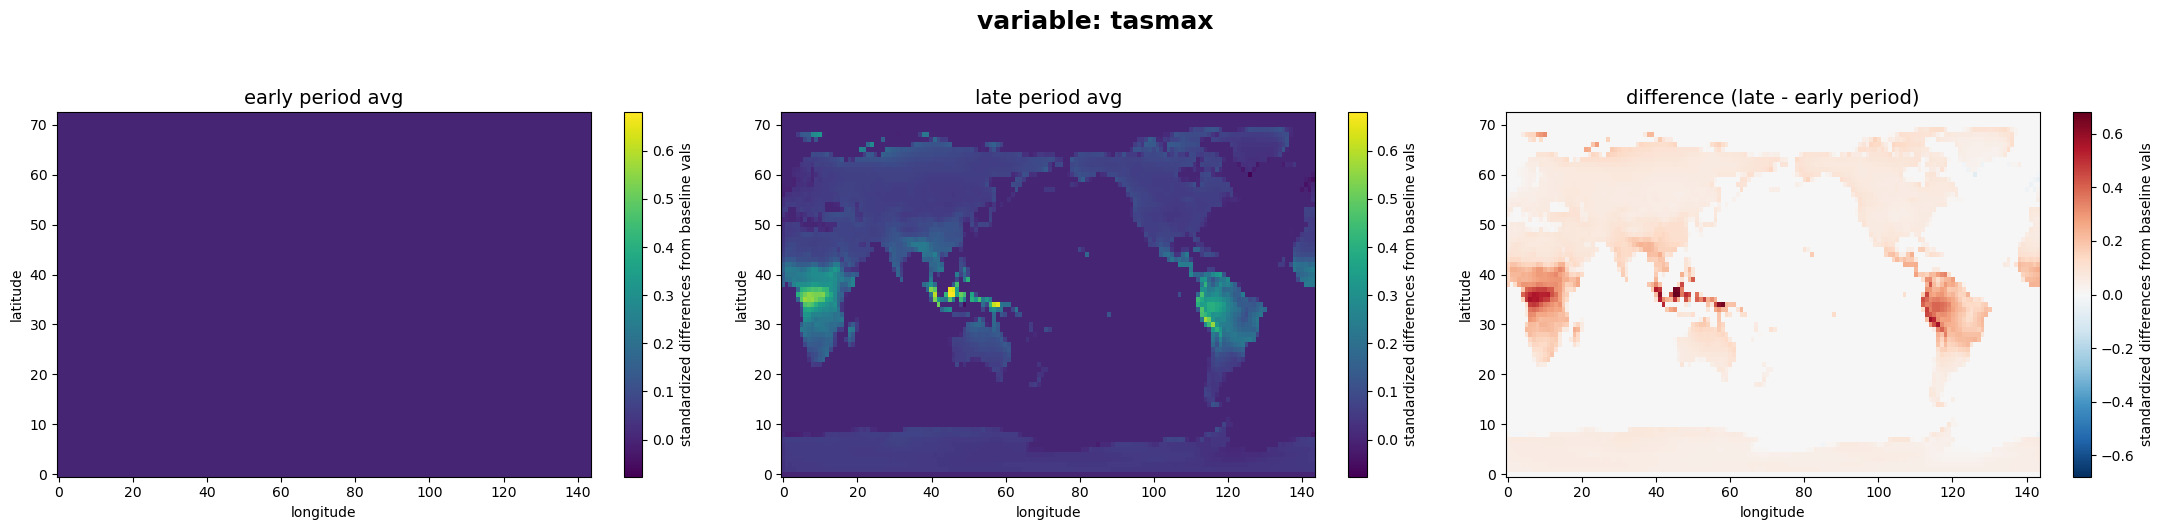

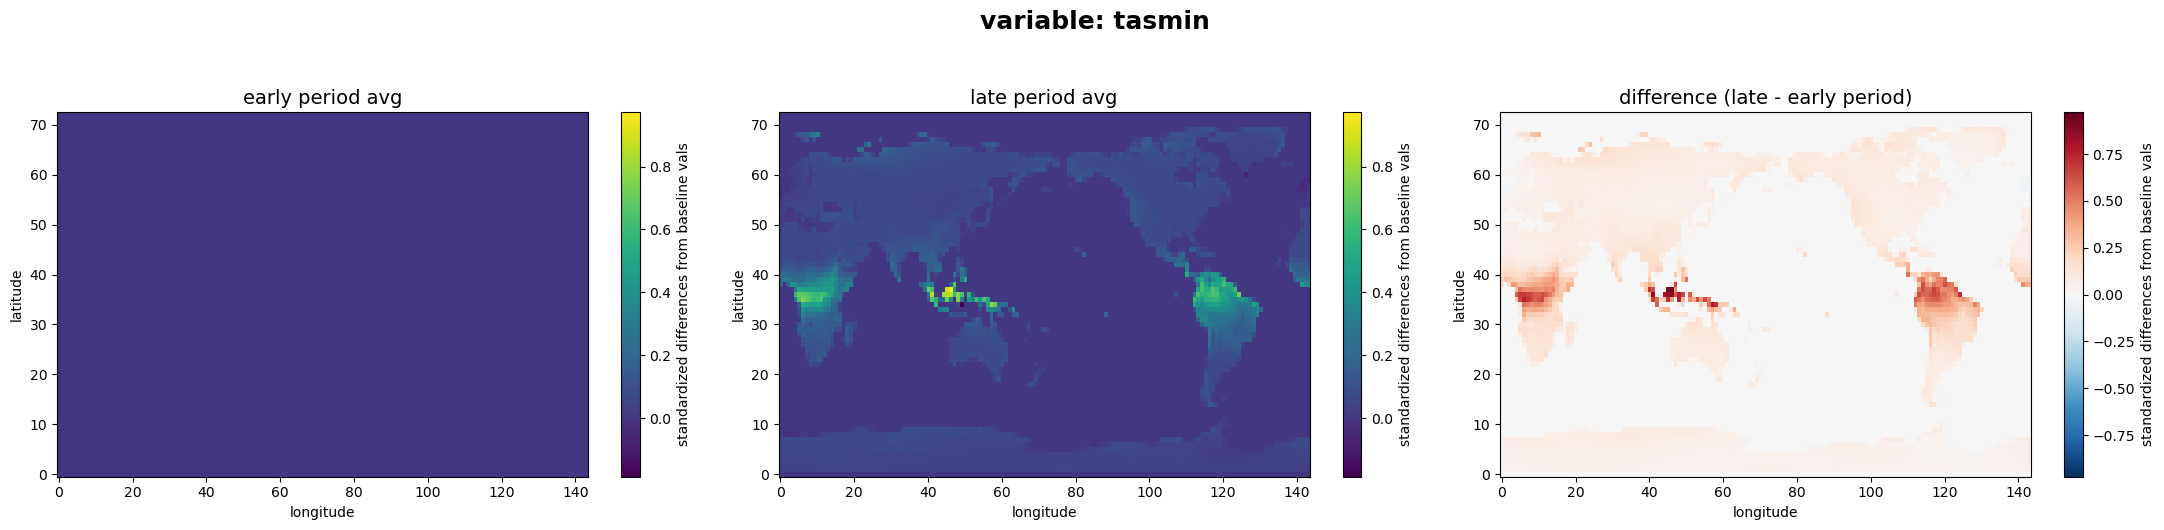

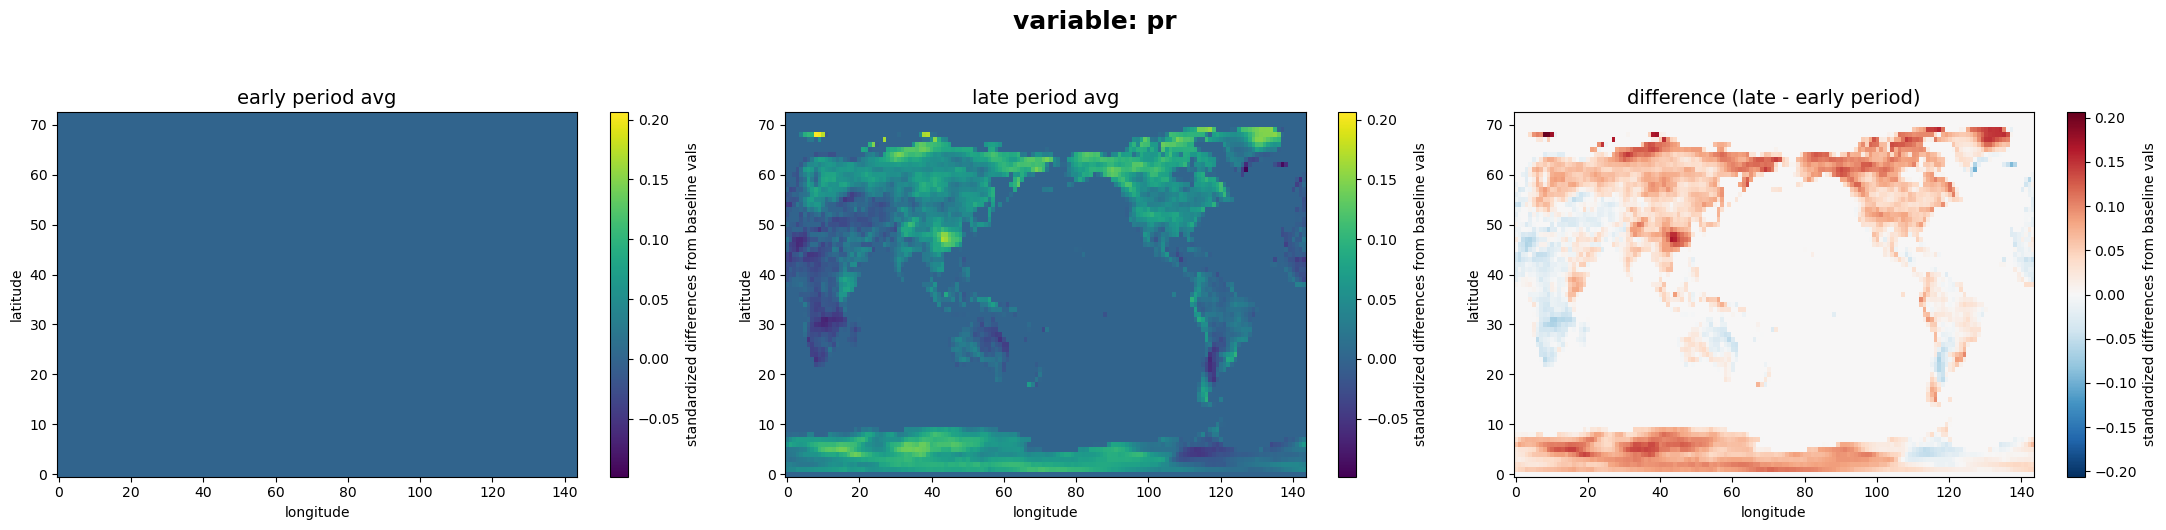

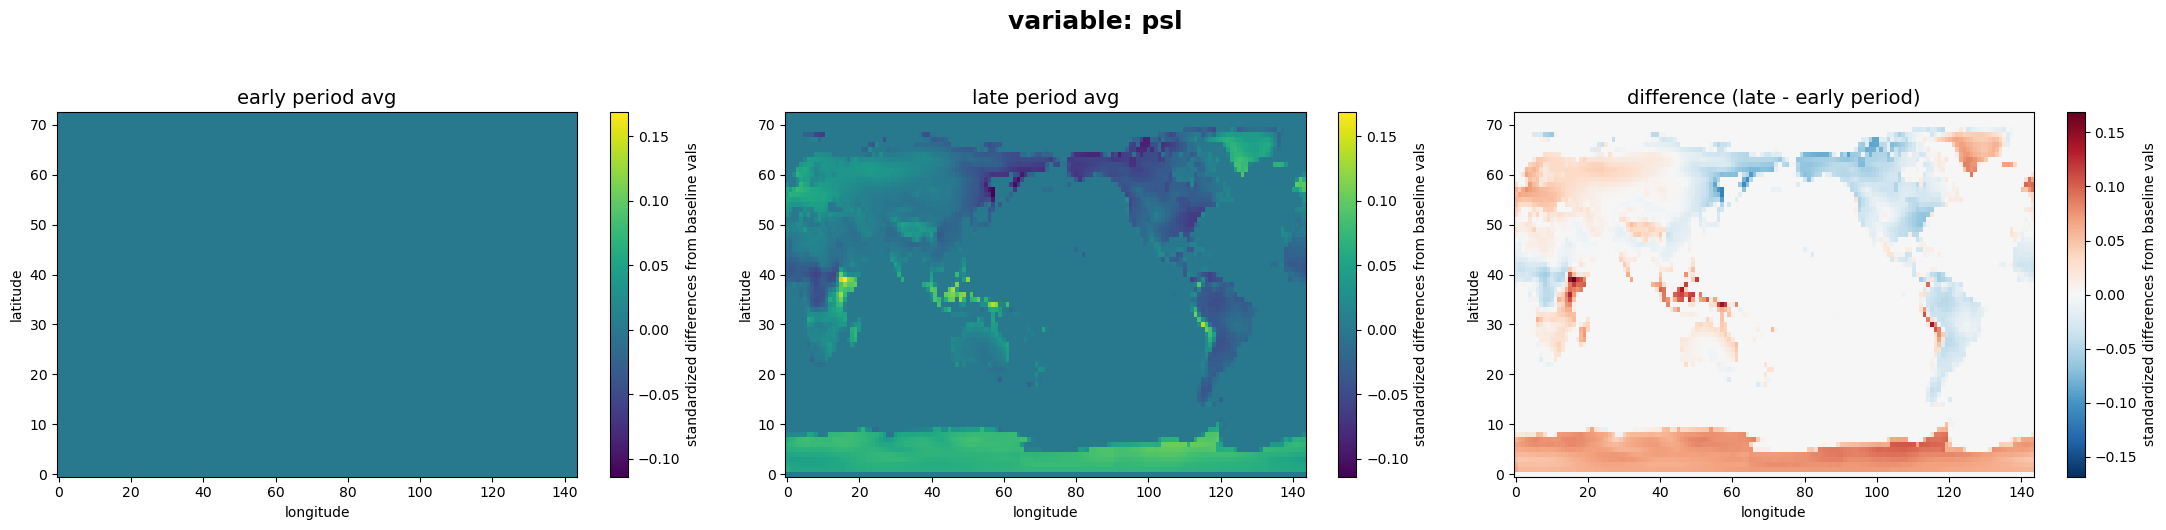

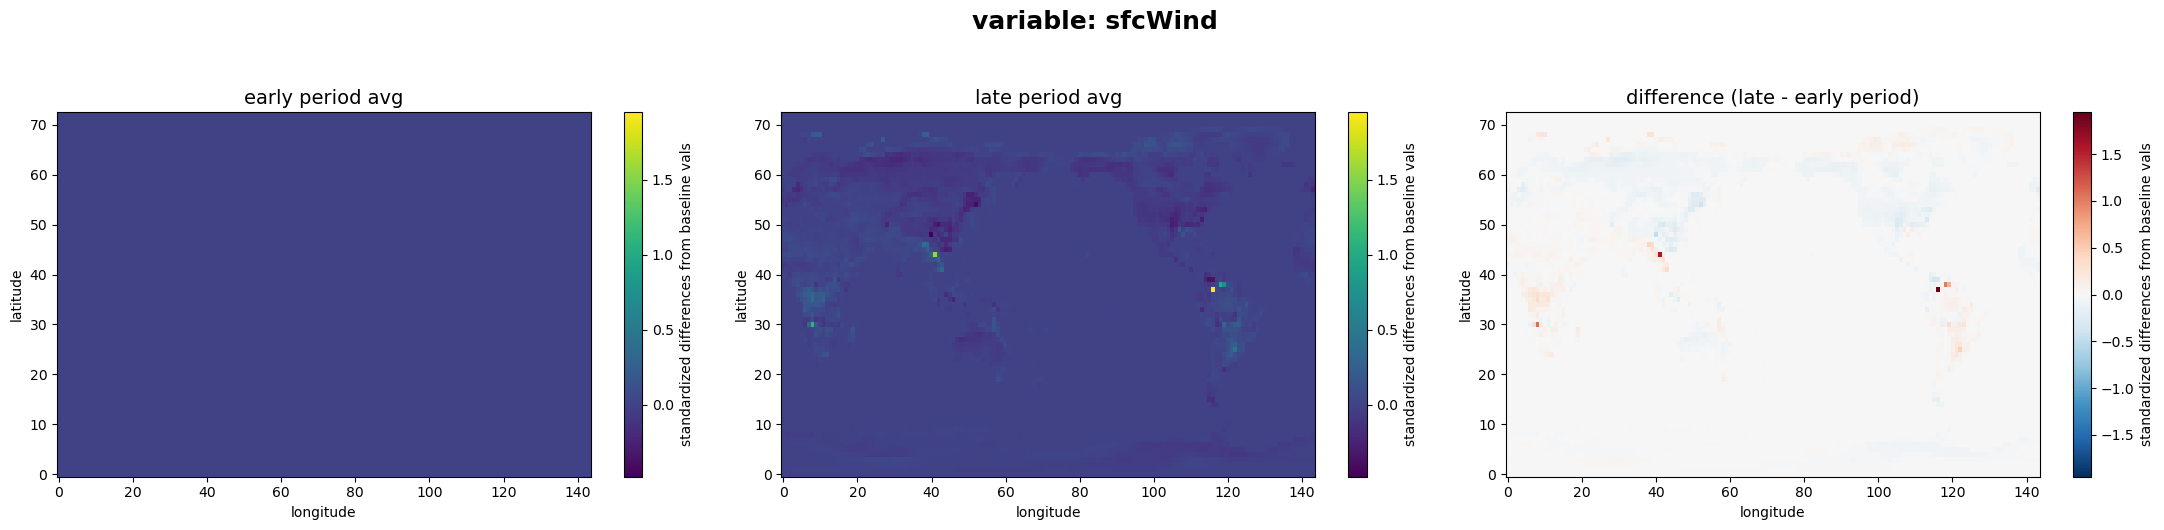

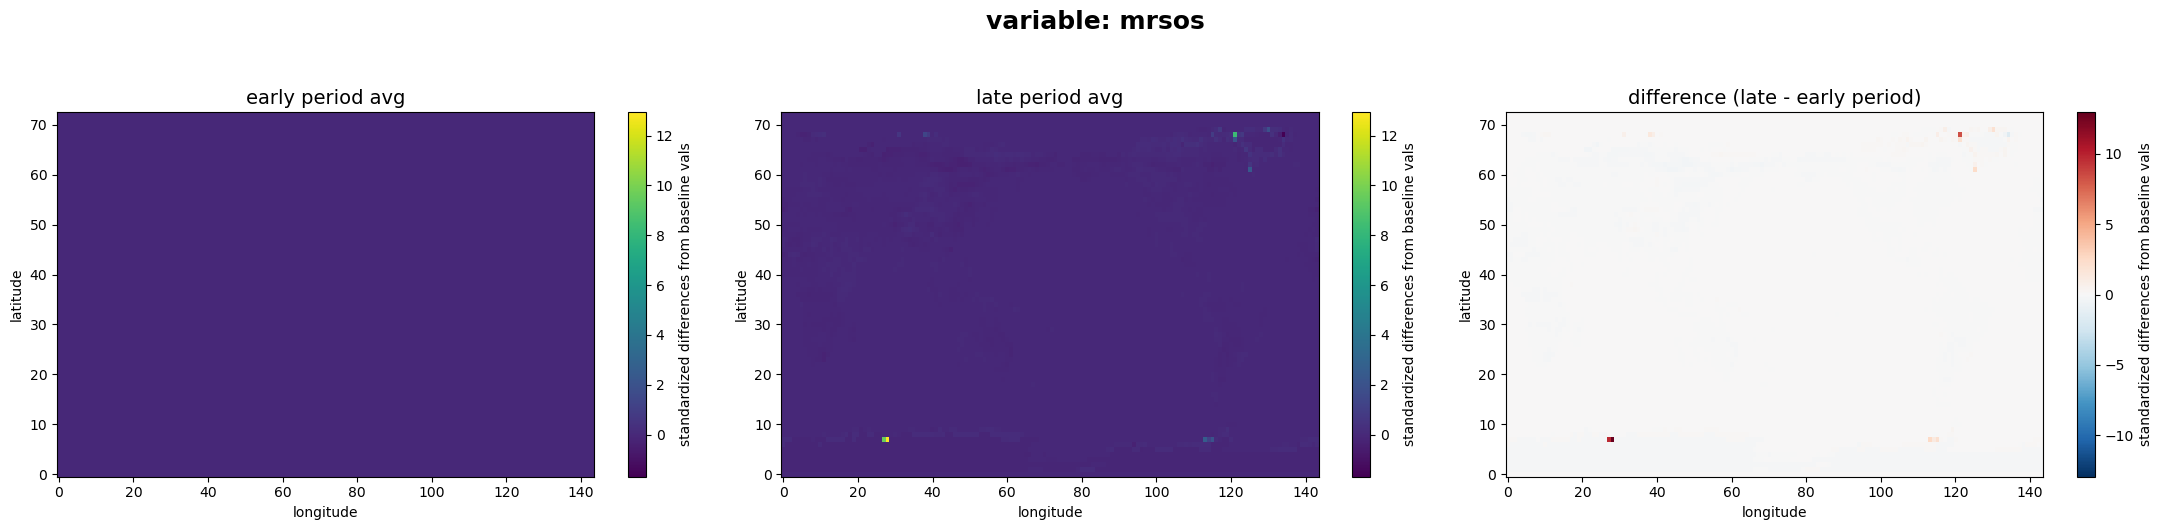

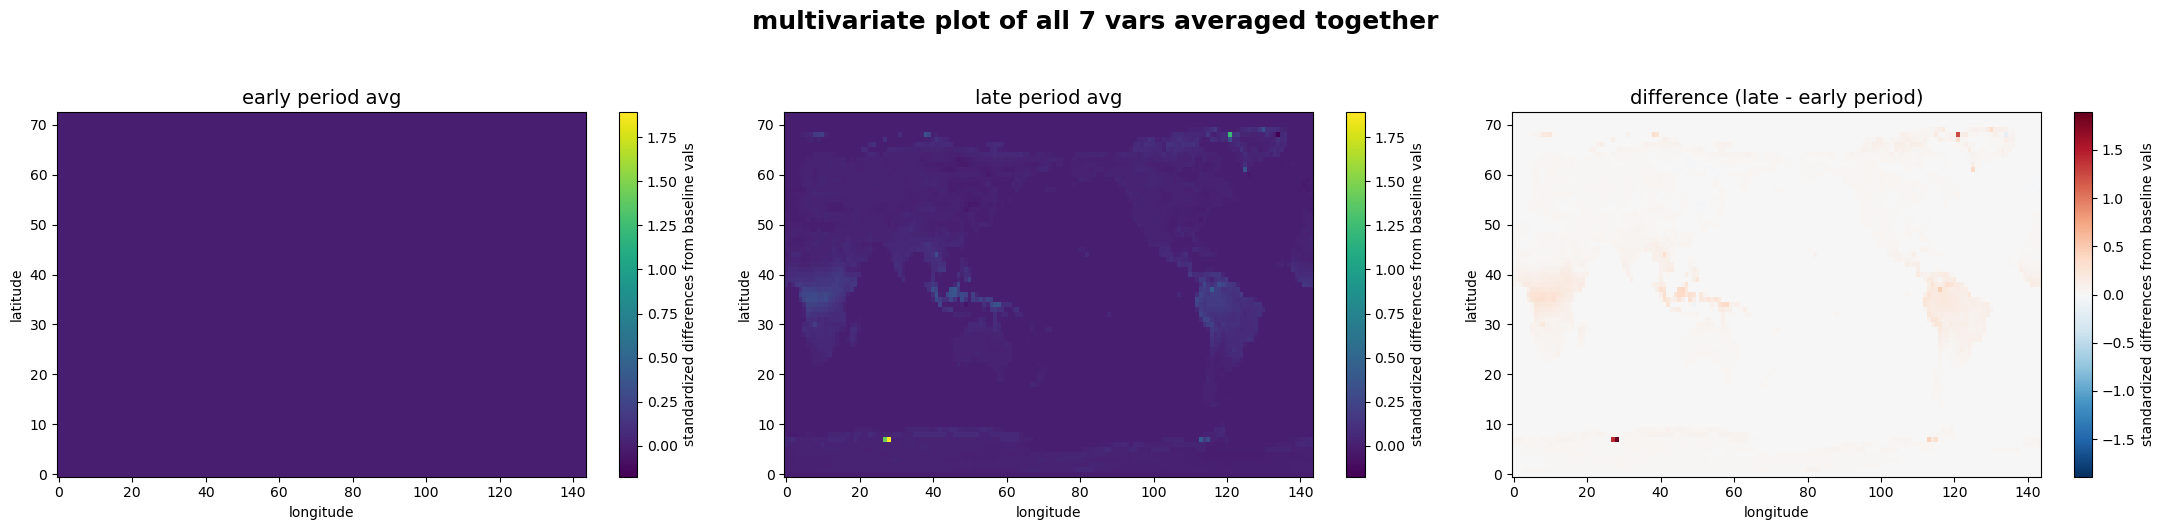

processing model: CNRM_ESM2-1


/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


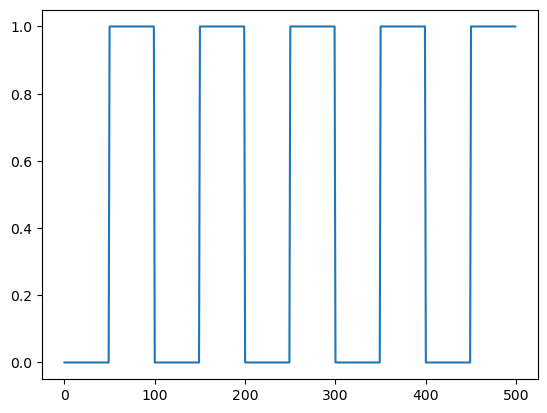

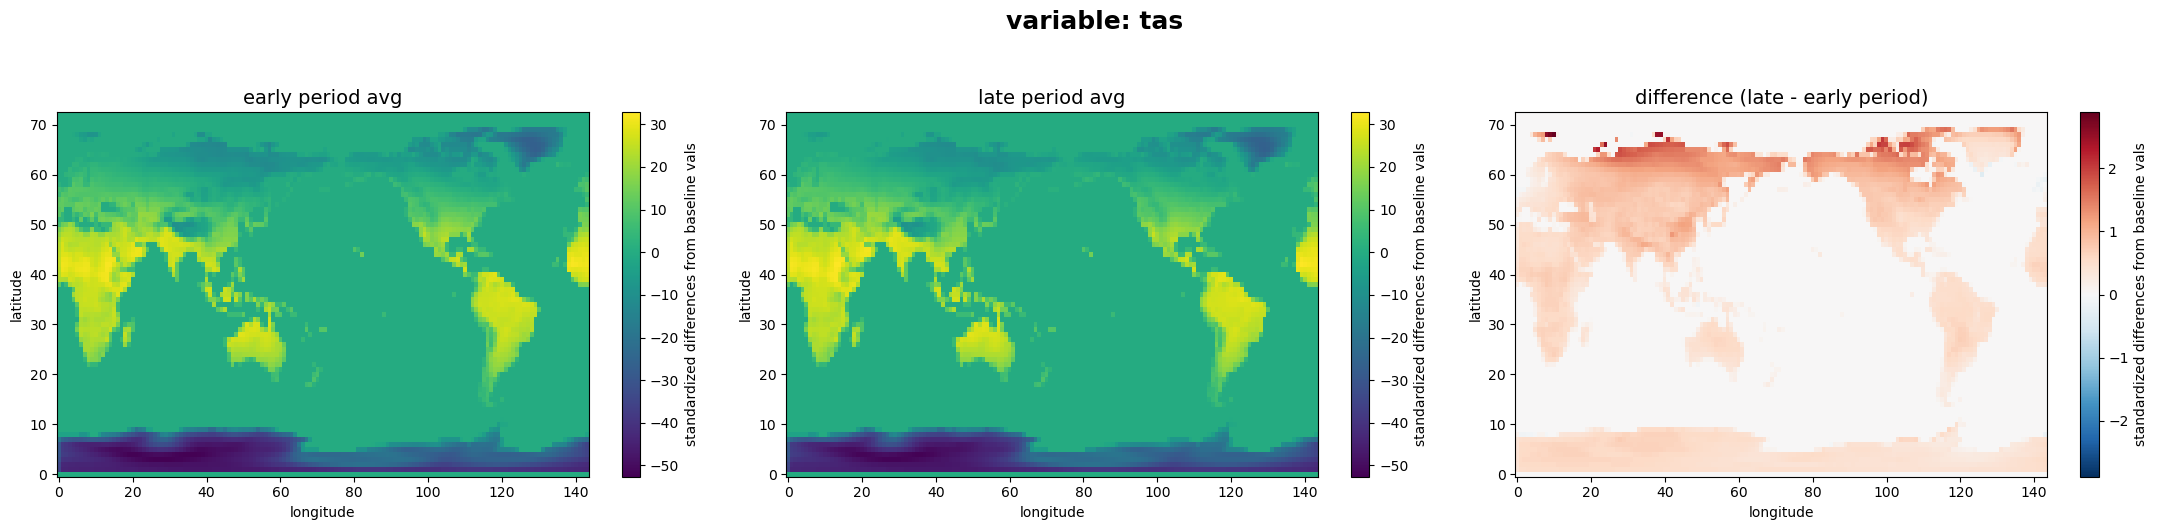

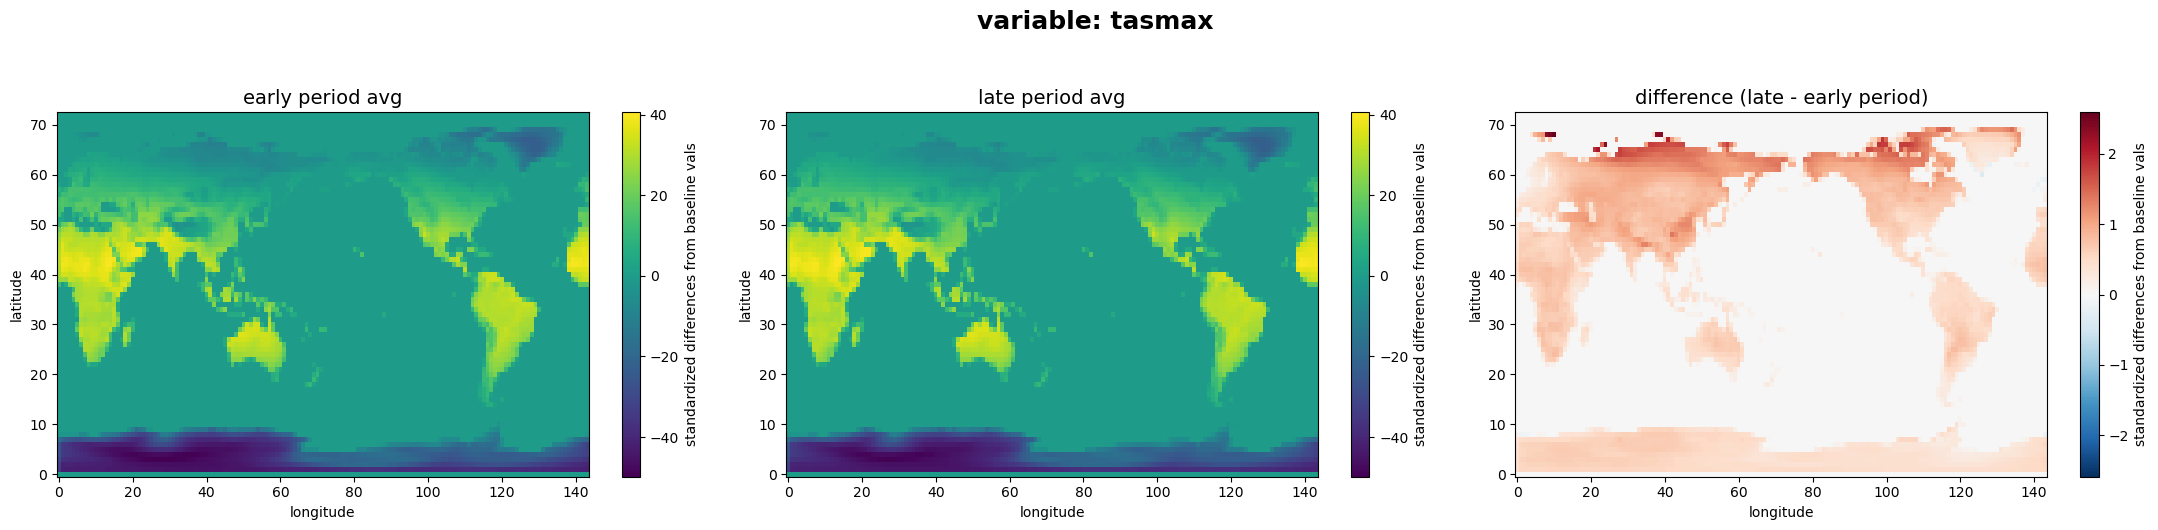

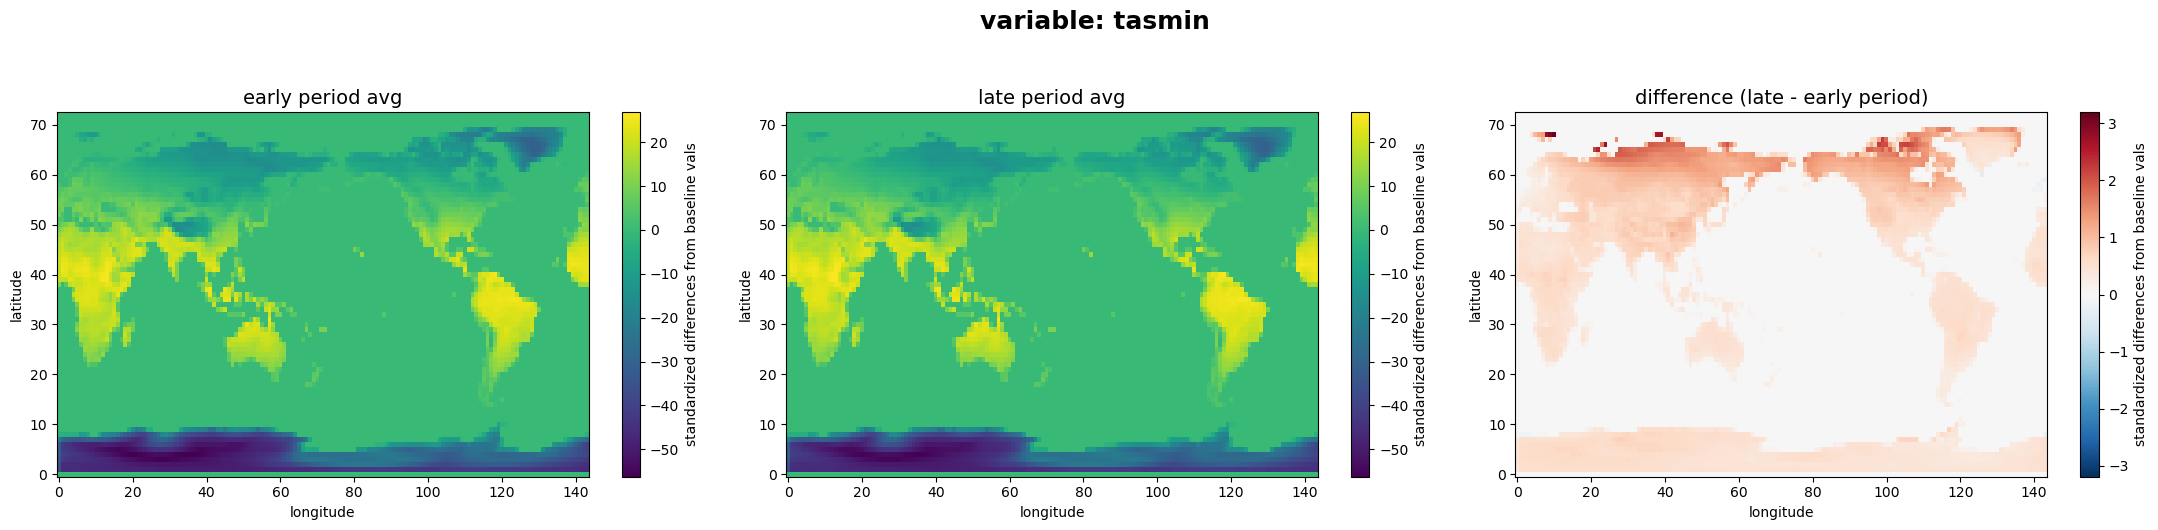

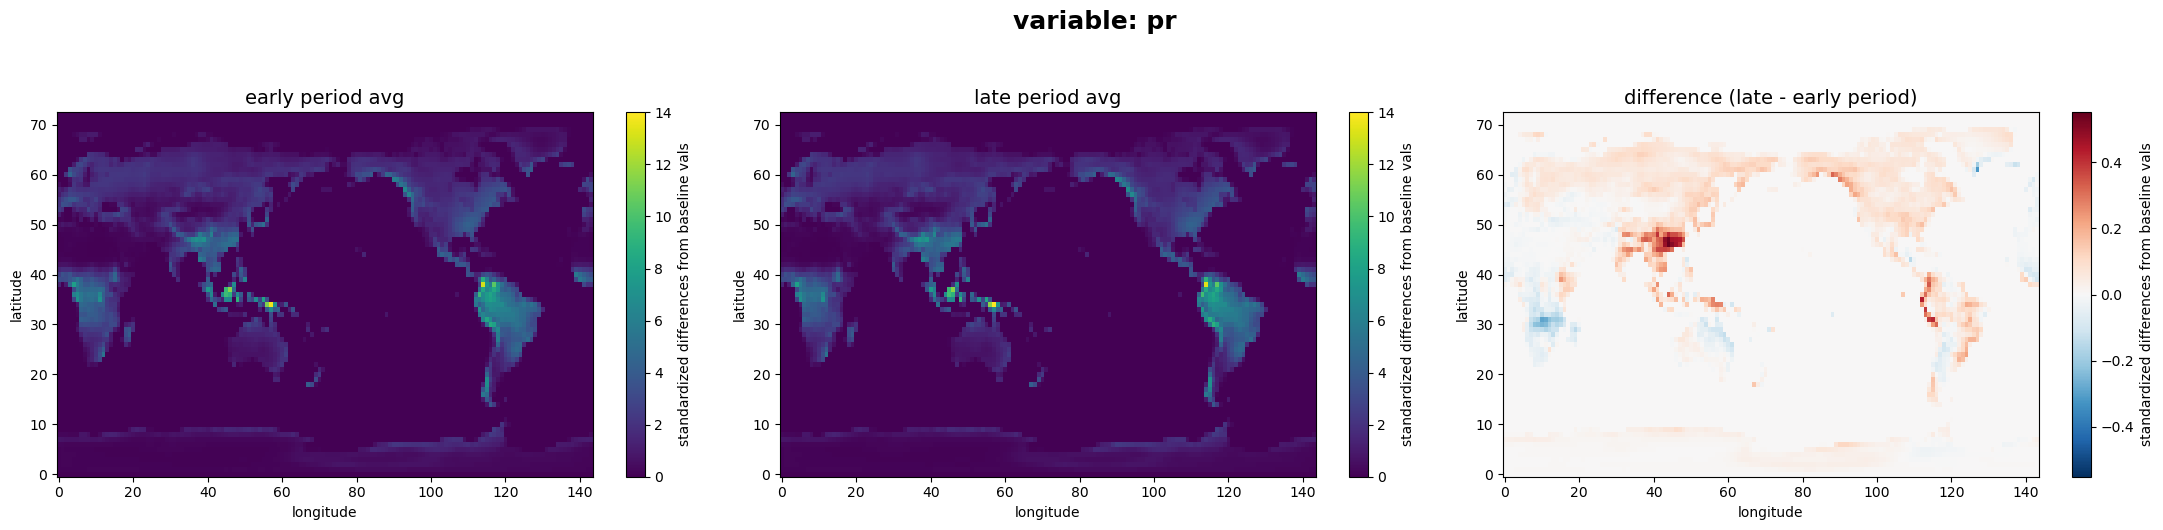

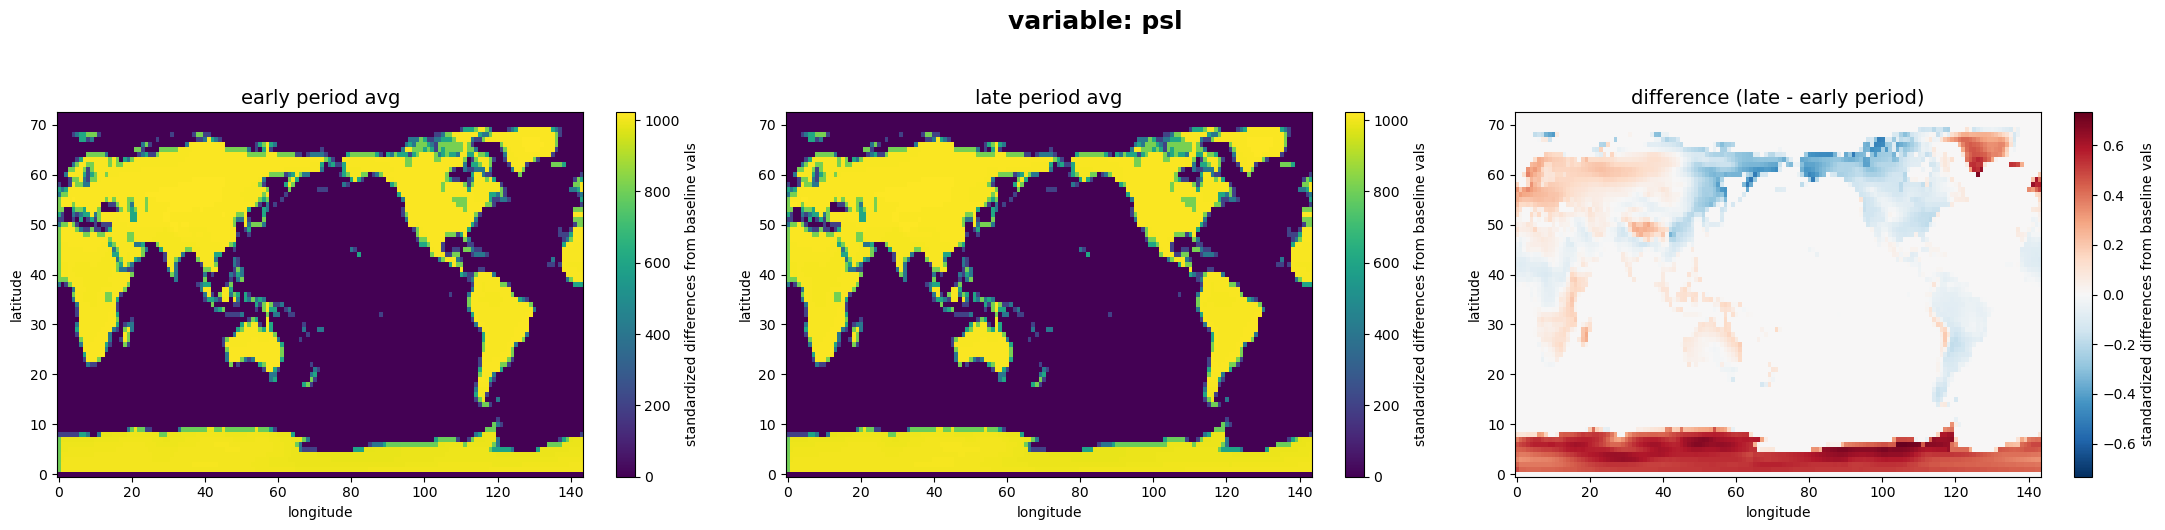

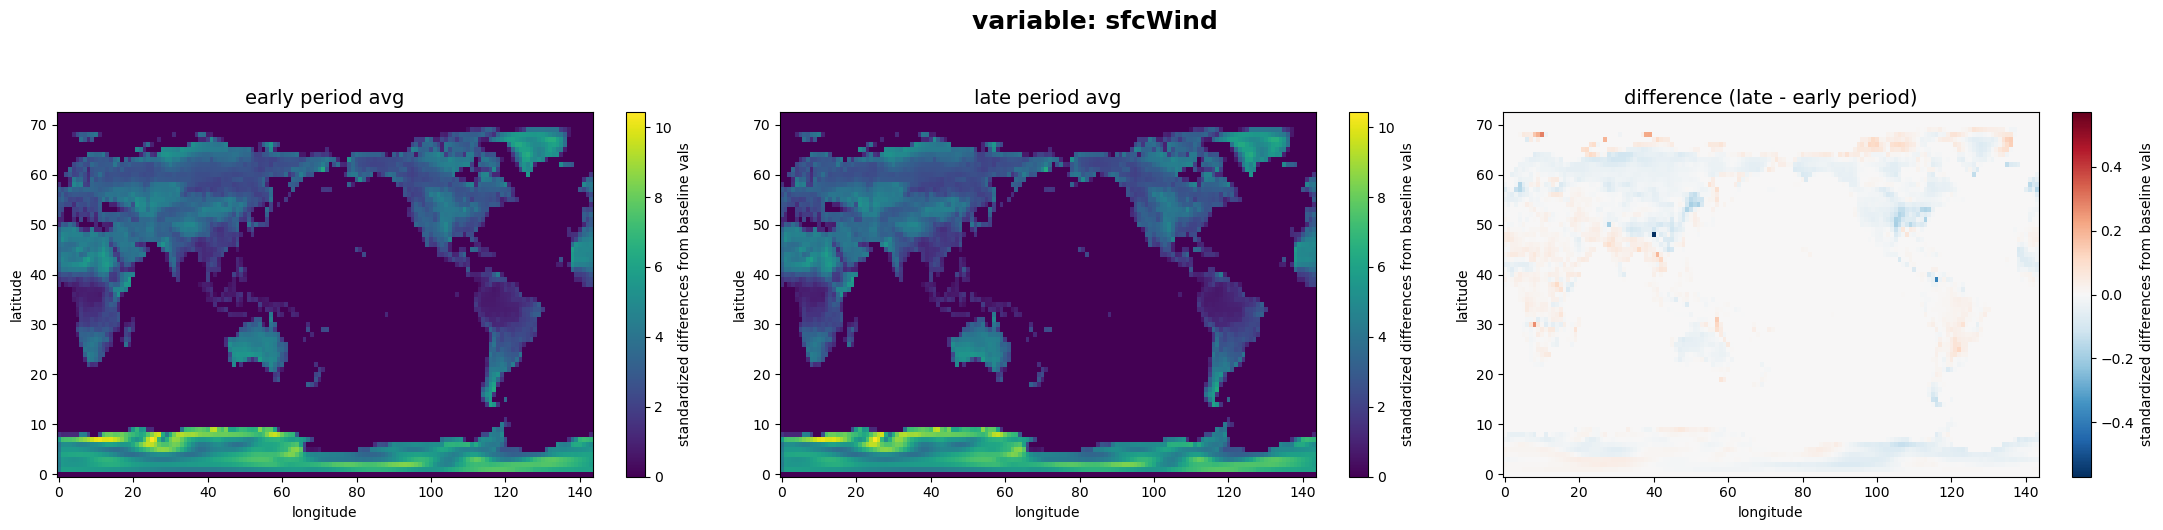

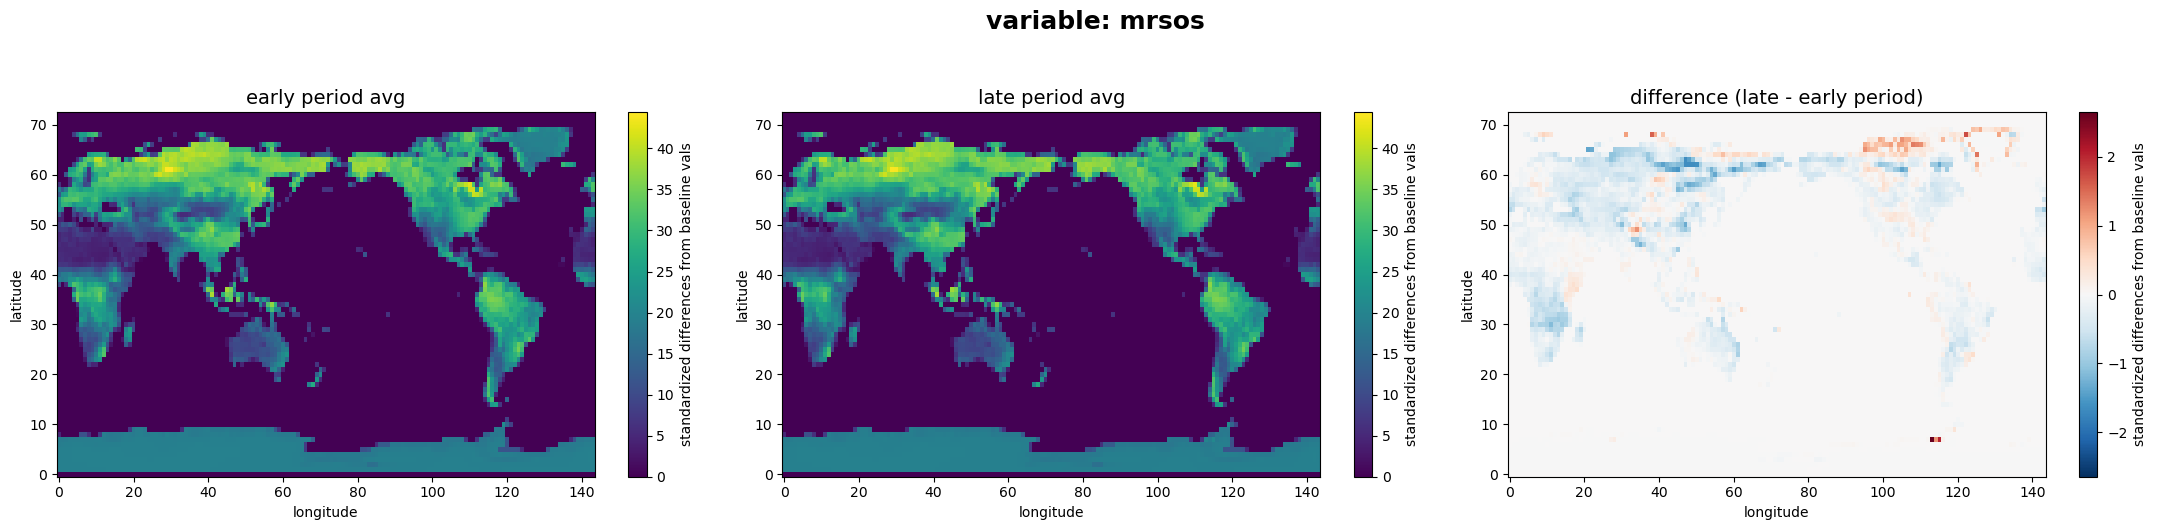

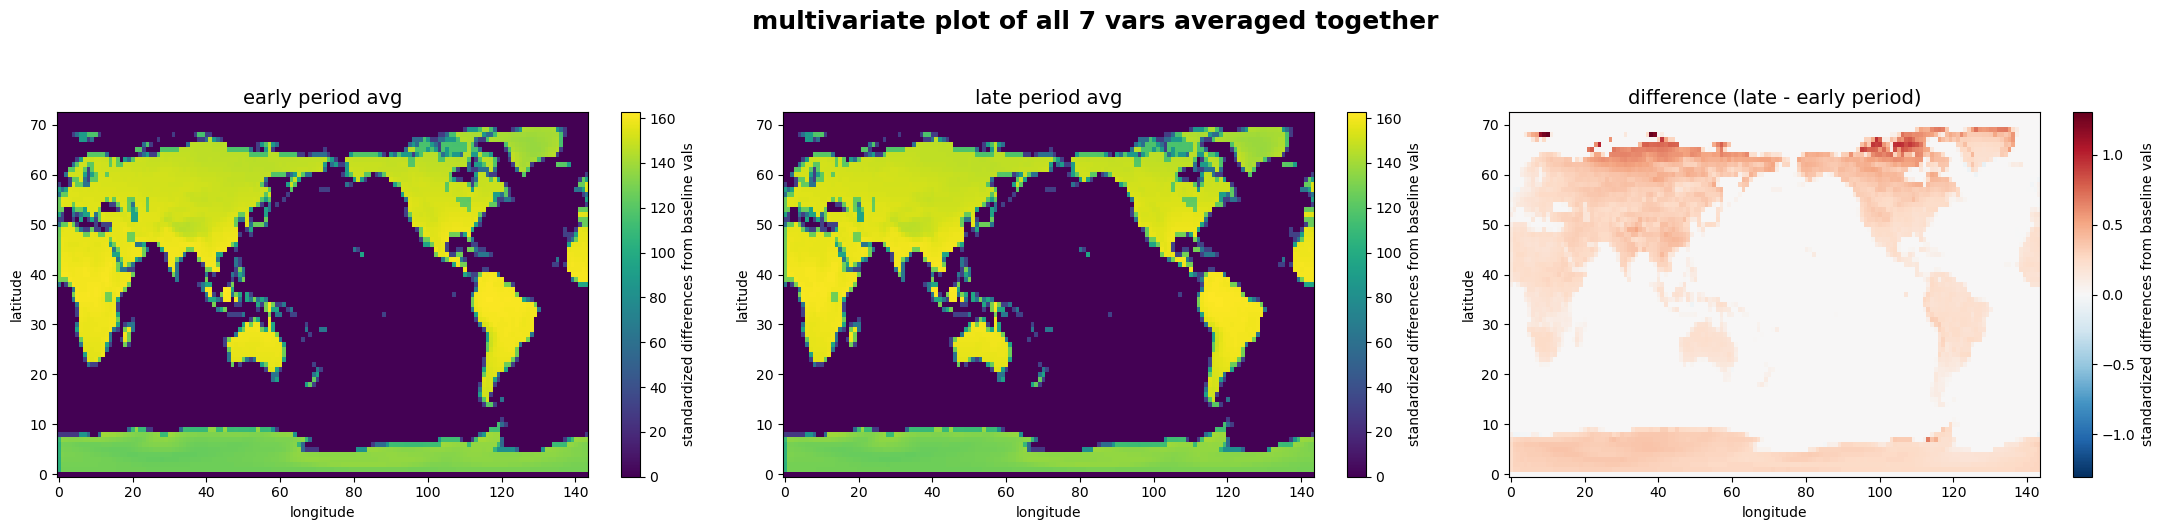

In [12]:
%run "data_prep_viz/prep/get_cnn_data_v3_sk.ipynb" 

In [6]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    return grads

In [7]:
def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    # 1. Ensure inputs and baseline are float32
    inputs = inputs.astype(np.float32)
    
    if baseline is None:
        # Fallback to zeros if no baseline provided
        baseline = np.zeros_like(inputs).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)
        # Ensure baseline has a leading dimension if it's a single mean map
        if baseline.ndim == inputs.ndim - 1:
            baseline = np.expand_dims(baseline, axis=0)

    # 2. Generate interpolation steps
    # We use np.linspace to create the scaling factors (alphas)
    alphas = np.linspace(0.0, 1.0, num_steps + 1)
    
    # 3. Compute Gradients along the path
    # We iterate through the interpolation path from baseline to input
    all_grads = []
    for alpha in alphas:
        # Interpolate: baseline + alpha * (input - baseline)
        step_input = baseline + alpha * (inputs - baseline)
        
        # Get gradients for this specific step
        grad = get_gradients(step_input, model, top_pred_idx=top_pred_idx)
        all_grads.append(grad)
    
    # 4. Convert to tensor for averaging
    # Shape: (num_steps + 1, batch, vars, lat, lon)
    all_grads = tf.convert_to_tensor(all_grads, dtype=tf.float32)

    # 5. Approximate the integral (Trapezoidal Rule)
    # Average the gradients of adjacent steps
    grads_at_step_ends = (all_grads[:-1] + all_grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_at_step_ends, axis=0)

    # 6. Final IG calculation: (input - baseline) * average gradient
    integrated_grads = (inputs - baseline) * avg_grads.numpy()
    
    return integrated_grads

In [8]:
def cnn_training(X_data, y_data, learning_rate=0.001, epochs=200, batch_size=64):
    # prep indices
    n_samples = X_data.shape[0]
    indices = np.arange(n_samples) # [0, 1, 2, ..., N-1]

    X = np.transpose(X_data, (0, 2, 3, 1))  # (N, lat, lon, 7)
    y = y_data.astype(np.float32)           # (N, 1)

    
    # split test set (50 samples) 
        # passing indices to keep track of the indices that are goin in the set 
    X_rem, X_test, y_rem, y_test, idx_rem, test_indices = train_test_split(
        X, y, indices,
        test_size=50,
        stratify=y
    )

    # val split (from remaning 450 samples)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X_rem, y_rem, idx_rem,
        test_size=50,
        stratify=y_rem
    )

    
    lat, lon = X_train.shape[1], X_train.shape[2]
    model = models.Sequential([
        layers.Input(shape=(lat, lon, 7)),
        
        #  CNN block (64 filters) with two convs, then pool
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 32 kernels (conv + pool)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 16 kernels (conv only)
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),             
        layers.Dense(50, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    # train model 
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Return everything needed for the large loop
    return model, X_train, y_train, X_test, y_test, test_indices

In [9]:

import xarray as xr

def run_climate_experiment(scenarios, early_starts, model_list, data_path):

    # initializing list to store results from each early/late period iteration
    all_results = []
    
    # looping thru each scenario (ssp119, ssp126)
    for scenario in scenarios:
        # for every early start year in early_starts list
        for early_start in early_starts:
            # make late period start years as 10 plus the early start year, going up to 2095
            late_starts = np.arange(early_start + 10, 2095, 10) 
            
            for late_start in late_starts:
                print(f"Processing: {scenario} | Early: {early_start} | Late: {late_start}")
                
                # prepping data for every early and late 10yr time period combo 
                X_data, y_data = get_cnn_tensors(
                    model_list, scenario, data_path, 
                    st_early=early_start, end_early=early_start+9, 
                    st_late=late_start, end_late=late_start+9
                )
                
                # training data 
                model, X_train, y_train, X_test, y_test, test_idx = cnn_training(X_data, y_data)
                
                # predicting
                preds = model.predict(X_test).flatten()
                
                # XAI STUFF: 
                # baseline is the mean of early period from training set
                early_idx = np.where(y_train == 0)[0]
                baseline = np.mean(X_train[early_idx], axis=0, keepdims=True)
                
                # getting late indices for X_test set 
                late_test_idx = np.where(y_test == 1)[0]
                ig_samples = X_test[late_test_idx]
                
                # integrated gradient calculation based on the early period baseline on the late period stuff 
                ig_output = get_integrated_gradients(ig_samples, model, baseline)
                if hasattr(ig_output, 'numpy'): 
                    ig_output = ig_output.numpy()

             
                # storing all the iteration data as a dict 
                iteration_data = {
                    'scenario': scenario,
                    'early_yr': early_start,
                    'late_yr': late_start,
                    'y_true': y_test,
                    'y_pred': preds,
                    'test_indices': test_idx,
                    'ig_heatmaps': ig_output 
                }
                # appending everything to the all_results list 
                all_results.append(iteration_data)

    # --- SAVING DATA ---
    save_results(all_results)
    return all_results

def save_results(results_list, filename="experiment_results.nc"):
    """
    Saves the nested results into a NetCDF file, which is ideal for 
    high-dimensional climate heatmaps.
    """
    # For a quick CSV of just the performance:
    summary_df = pd.DataFrame([{
        'scenario': r['scenario'],
        'early': r['early_yr'],
        'late': r['late_yr'],
        'mean_pred': np.mean(r['y_pred'])
    } for r in results_list])
    summary_df.to_csv("experiment_summary.csv", index=False)
    
    print("Results saved to experiment_summary.csv and (optionally) NetCDF.")


In [13]:
results = run_climate_experiment(['ssp119', 'ssp126'], [2015, 2025, 2035, 2045, 2055, 2065, 2075], model_list, data_path) # Skip 2085, too late (cannot compare)
# 42 experiments, will take a while to run - suggested to run overnight
# Run this 6+ times to generate and quantify uncertainty

Processing: ssp119 | Early: 2015 | Late: 2025
processing model: CNRM_ESM2-1


/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/1044987437.py:94: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_4108/1044987437.py:118: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


NameError: name 'models' is not defined